# MERLIN Classifier Sanity Check

This version is optimized for presentation use: simple charts, large labels, and one clean dashboard for the full dataset plus one dashboard per language.

Included views:
- Ground-truth vs prediction distribution
- Multiclass confusion matrix
- Simple `TP / FP / FN / TN` square using a micro-averaged one-vs-rest view

In [1]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.size": 11,
})

CEFR_LEVELS = ["A1", "A2", "B1", "B2", "C1", "C2"]
LEVEL_TO_INDEX = {level: idx for idx, level in enumerate(CEFR_LEVELS)}


def resolve_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        target = candidate / "universal-cefr-classifier" / "outputs" / "merlin_interesting_data_cefr_predictions.jsonl"
        if target.exists():
            return candidate
    raise FileNotFoundError("Could not resolve repo root from the current working directory.")


REPO_ROOT = resolve_repo_root()
PREDICTIONS_PATH = REPO_ROOT / "universal-cefr-classifier" / "outputs" / "merlin_interesting_data_cefr_predictions.jsonl"
PREDICTIONS_PATH

PosixPath('/Users/ericbennett/Desktop/github/language-learning-llms/universal-cefr-classifier/outputs/merlin_interesting_data_cefr_predictions.jsonl')

In [2]:
all_records = []
valid_records = []
excluded_records = []

with PREDICTIONS_PATH.open() as infile:
    for line in infile:
        record = json.loads(line)
        all_records.append(record)
        truth = record.get("author_level")
        pred = record.get("predicted_cefr")
        if truth in LEVEL_TO_INDEX and pred in LEVEL_TO_INDEX:
            valid_records.append(record)
        else:
            excluded_records.append(record)

y_true = [record["author_level"] for record in valid_records]
y_pred = [record["predicted_cefr"] for record in valid_records]
accuracy = sum(truth == pred for truth, pred in zip(y_true, y_pred)) / len(valid_records)
excluded_counts = Counter(record.get("author_level", "MISSING") for record in excluded_records)

print(f"Total rows:          {len(all_records):,}")
print(f"Valid CEFR rows:     {len(valid_records):,}")
print(f"Excluded rows:       {len(excluded_records):,}")
print(f"Exact-match acc.:    {accuracy:.1%}")

if excluded_records:
    print("\nExcluded labels:")
    for label, count in sorted(excluded_counts.items()):
        print(f"  {label}: {count}")

Total rows:          2,287
Valid CEFR rows:     2,278
Excluded rows:       9
Exact-match acc.:    83.0%

Excluded labels:
  EMPTY: 3
  unrated: 6


In [3]:
def extract_arrays(records):
    y_true = [record["author_level"] for record in records]
    y_pred = [record["predicted_cefr"] for record in records]
    return y_true, y_pred


def build_confusion(y_true, y_pred):
    matrix = np.zeros((len(CEFR_LEVELS), len(CEFR_LEVELS)), dtype=int)
    for truth, pred in zip(y_true, y_pred):
        matrix[LEVEL_TO_INDEX[truth], LEVEL_TO_INDEX[pred]] += 1
    return matrix


def plot_distribution(ax, y_true, y_pred):
    truth_counts = Counter(y_true)
    pred_counts = Counter(y_pred)
    x = np.arange(len(CEFR_LEVELS))
    width = 0.38
    truth_values = np.array([truth_counts[level] for level in CEFR_LEVELS])
    pred_values = np.array([pred_counts[level] for level in CEFR_LEVELS])

    truth_bars = ax.bar(x - width / 2, truth_values, width=width, color="#4C78A8", label="Ground truth")
    pred_bars = ax.bar(x + width / 2, pred_values, width=width, color="#F58518", label="Predictions")

    ax.set_title("Distribution by CEFR Level")
    ax.set_xlabel("CEFR level")
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(CEFR_LEVELS)
    ax.legend(frameon=False, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

    ymax = max(truth_values.max(), pred_values.max())
    ax.set_ylim(0, ymax * 1.18)
    for bars in (truth_bars, pred_bars):
        for bar in bars:
            value = int(bar.get_height())
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ymax * 0.02,
                f"{value}",
                ha="center",
                va="bottom",
                fontsize=9,
            )


def plot_confusion(ax, confusion):
    image = ax.imshow(confusion, cmap="Blues")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground truth")
    ax.set_xticks(np.arange(len(CEFR_LEVELS)))
    ax.set_yticks(np.arange(len(CEFR_LEVELS)))
    ax.set_xticklabels(CEFR_LEVELS)
    ax.set_yticklabels(CEFR_LEVELS)

    threshold = confusion.max() * 0.55 if confusion.max() else 0
    for row in range(confusion.shape[0]):
        for col in range(confusion.shape[1]):
            color = "white" if confusion[row, col] >= threshold else "black"
            ax.text(col, row, f"{confusion[row, col]}", ha="center", va="center", color=color, fontsize=10)

    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
def show_dashboard(records, title):
    y_true, y_pred = extract_arrays(records)
    confusion = build_confusion(y_true, y_pred)
    accuracy = sum(truth == pred for truth, pred in zip(y_true, y_pred)) / len(records)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.2, 1]})
    plot_distribution(axes[0], y_true, y_pred)
    plot_confusion(axes[1], confusion)
    fig.suptitle(f"{title} | exact-match accuracy: {accuracy:.1%} | n = {len(records):,}", fontsize=16, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

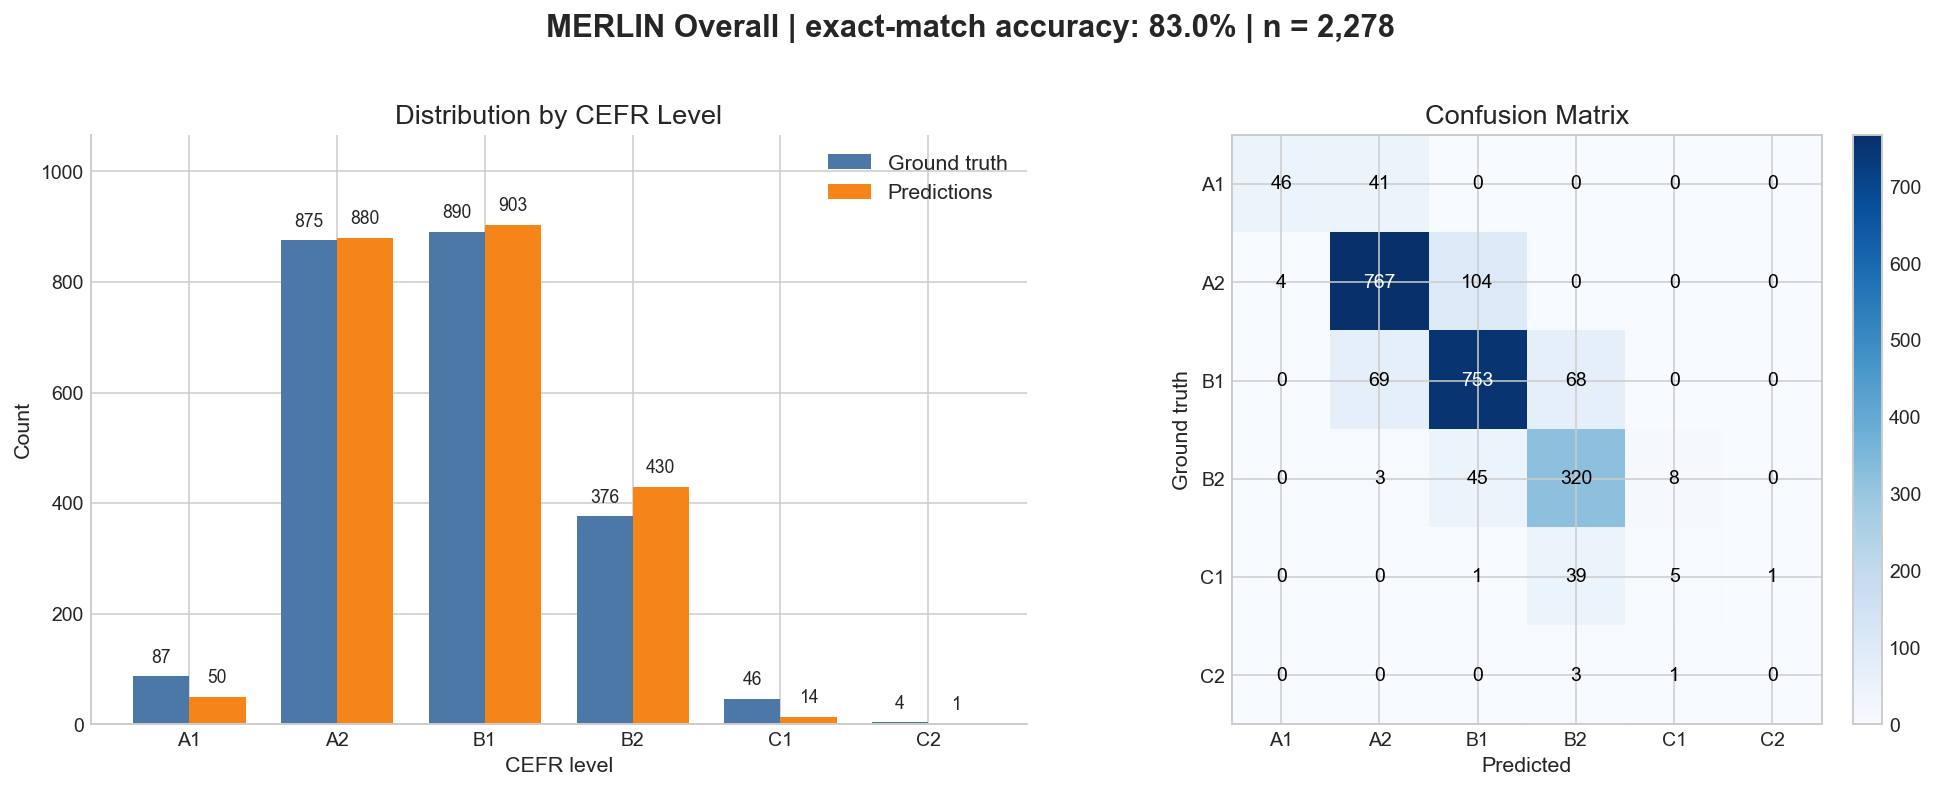

In [4]:
show_dashboard(valid_records, "MERLIN Overall")

## Per-Language Dashboards

Each language gets the same presentation-friendly layout.

Czech: n = 439, exact-match accuracy = 77.9%


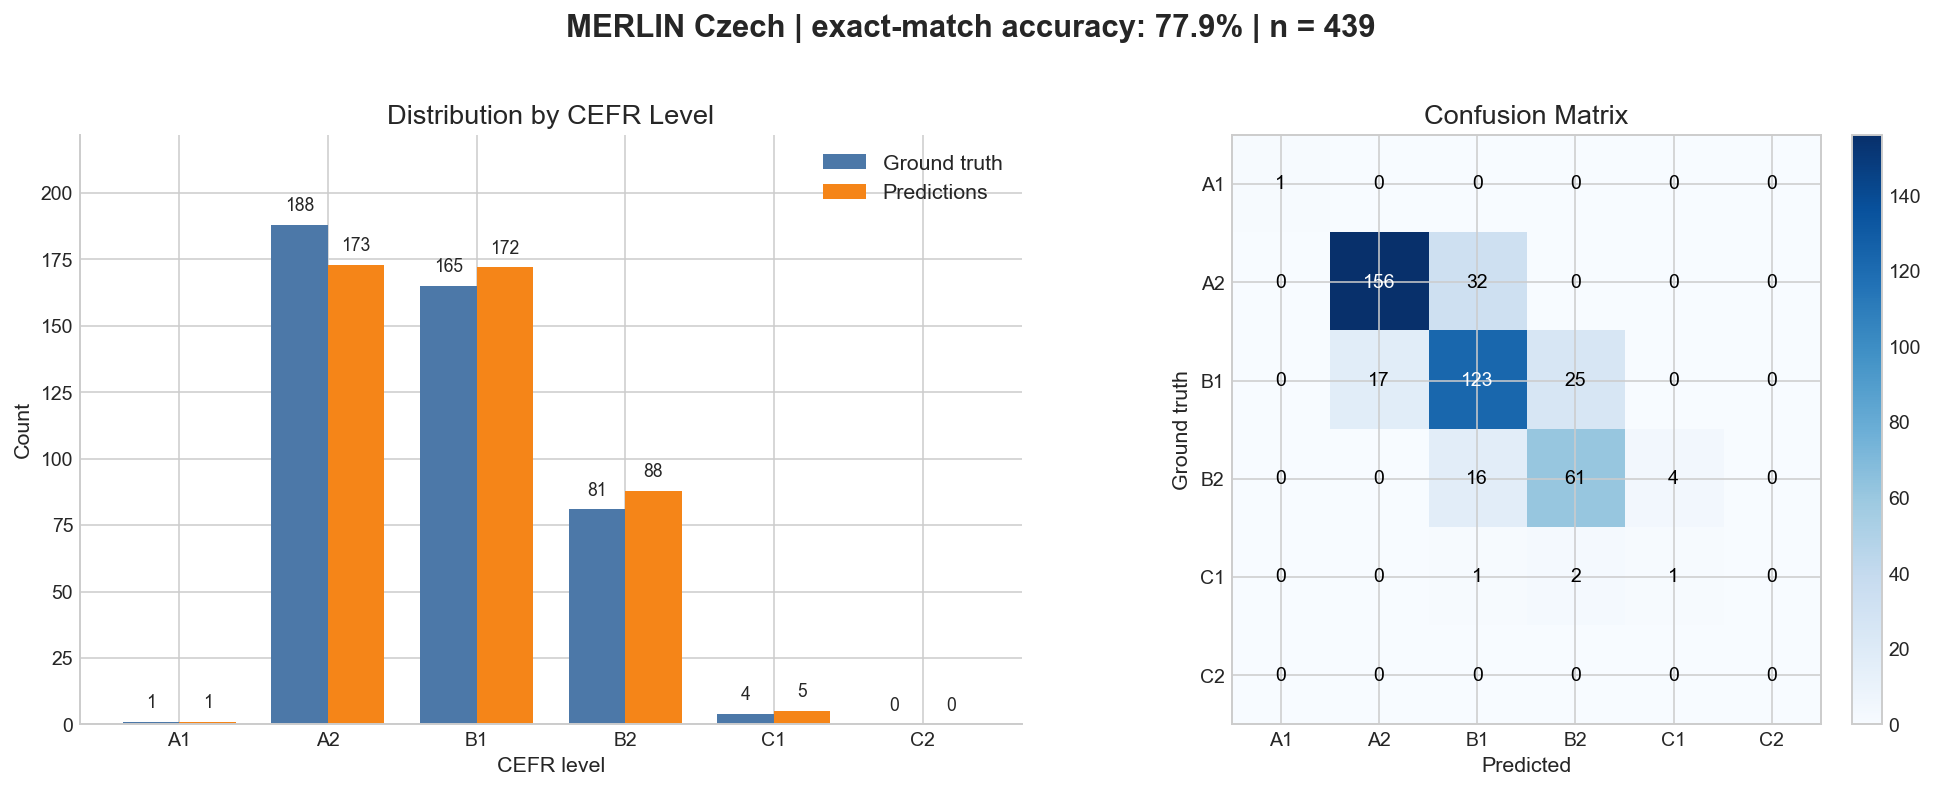

German: n = 1,033, exact-match accuracy = 79.7%


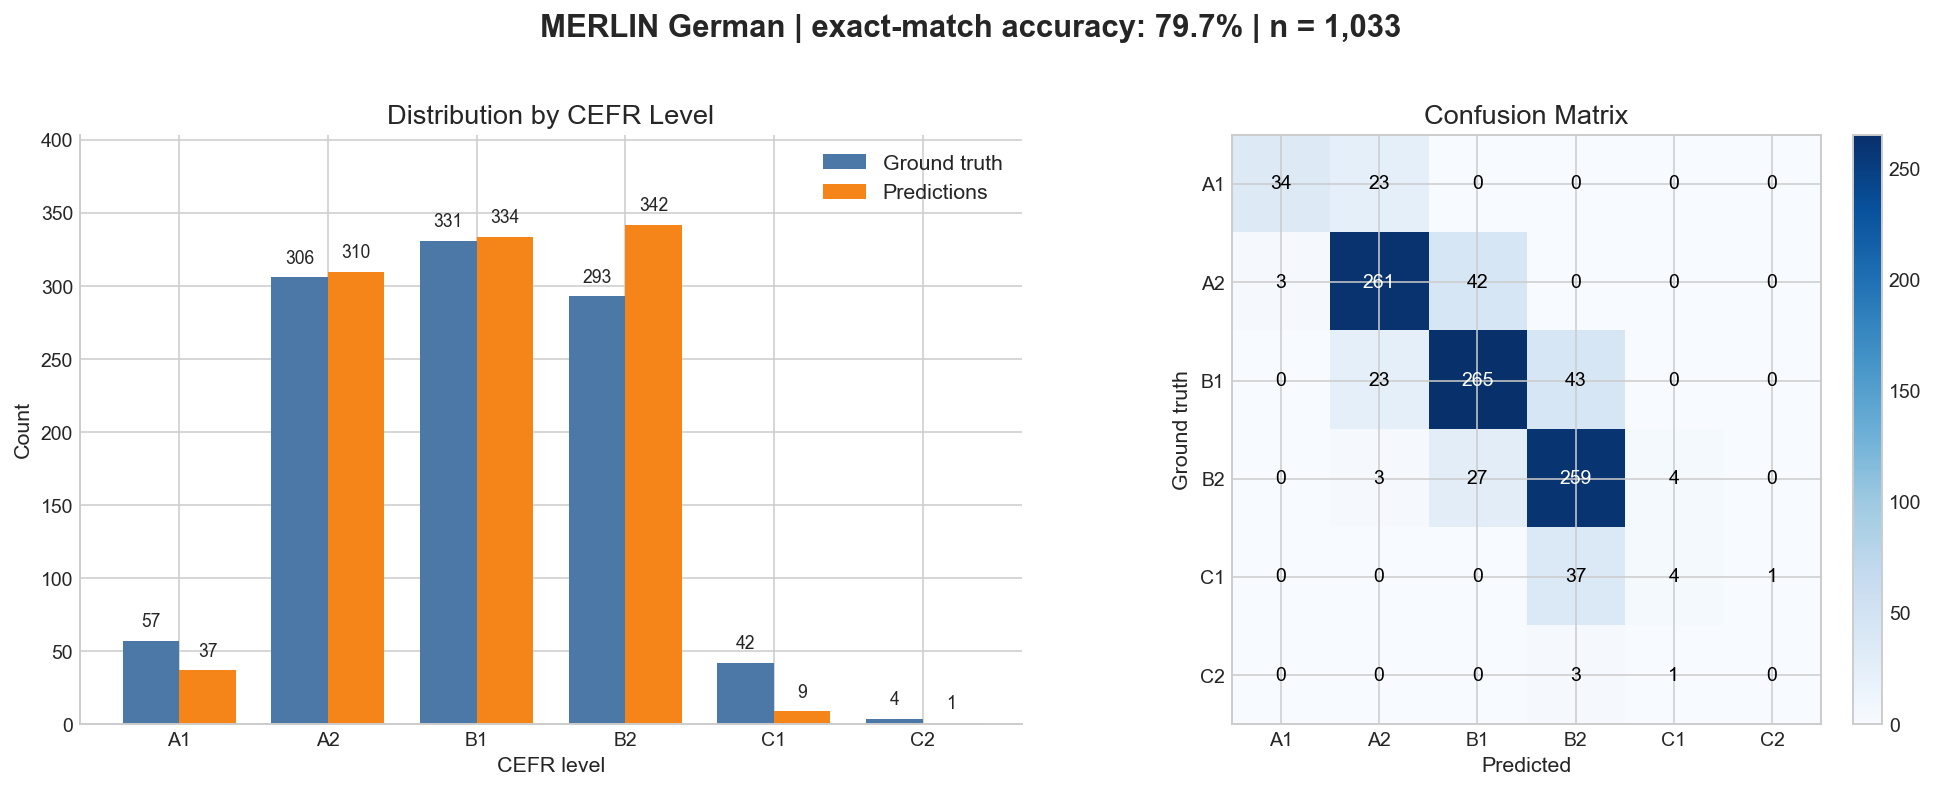

Italian: n = 806, exact-match accuracy = 90.1%


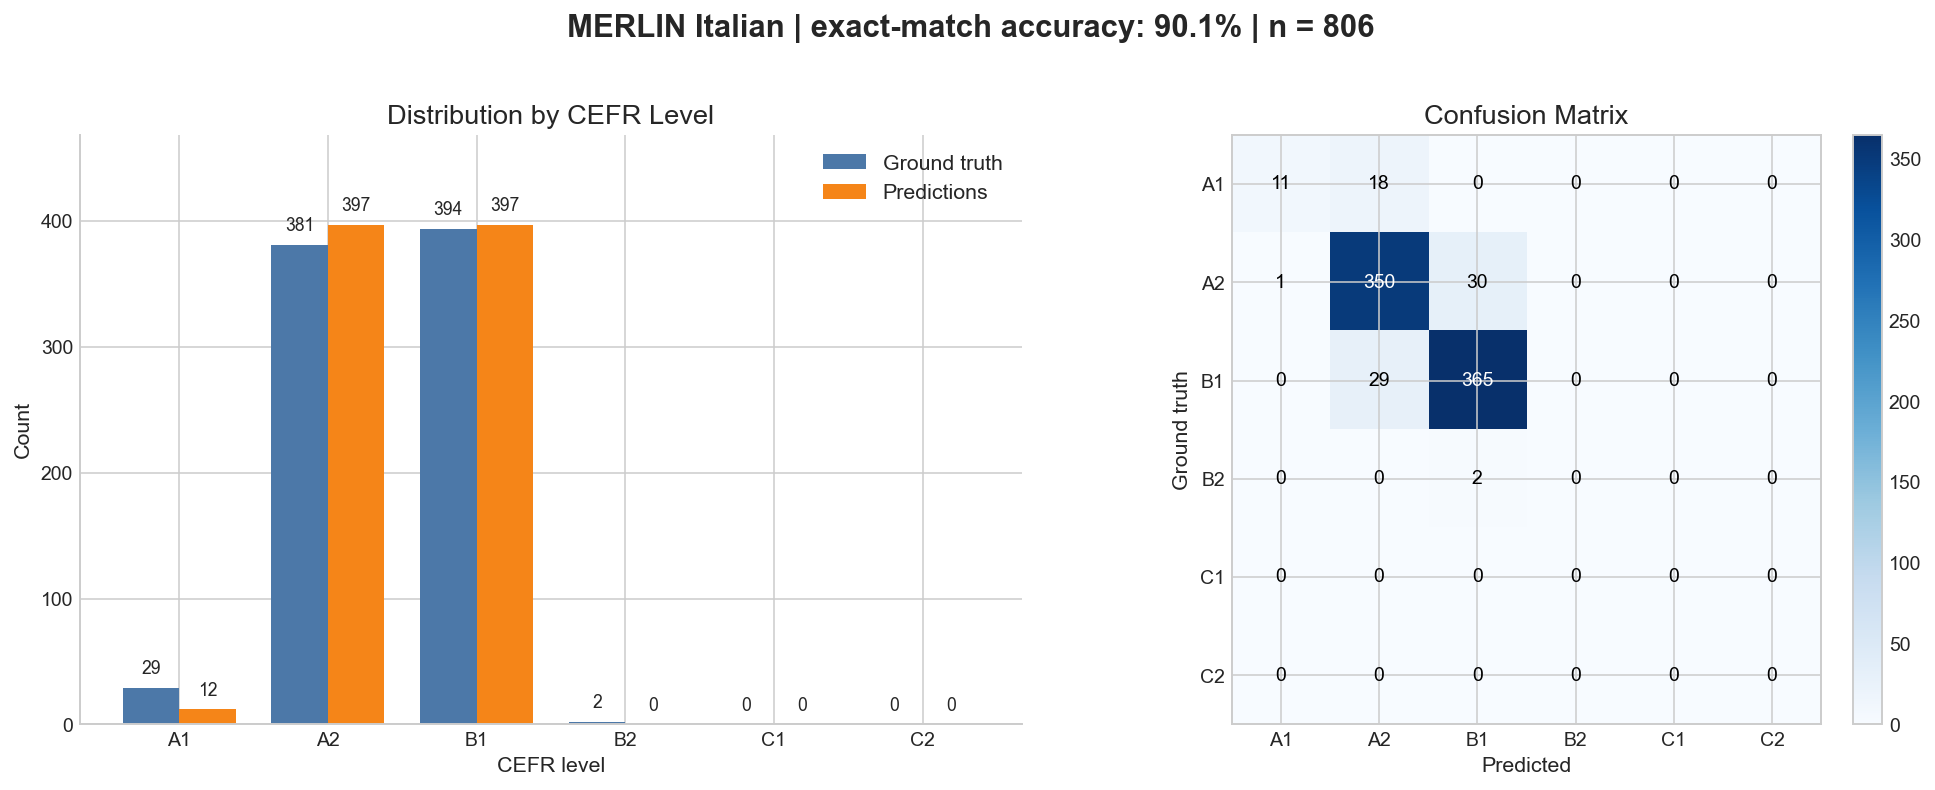

In [5]:
languages = sorted({record["language"] for record in valid_records})

for language in languages:
    language_records = [record for record in valid_records if record["language"] == language]
    language_true, language_pred = extract_arrays(language_records)
    language_accuracy = sum(truth == pred for truth, pred in zip(language_true, language_pred)) / len(language_records)
    print(f"{language}: n = {len(language_records):,}, exact-match accuracy = {language_accuracy:.1%}")
    show_dashboard(language_records, f"MERLIN {language}")